---
authors:
  - name: Juniper Tyree
    orcid: 0000-0002-7923-9609
    affiliations:
      - name: University of Helsinki
        ror: 040af2s02
    github: juntyr
  - name: Samuel Li
    orcid: 0000-0001-8295-2248
    affiliations:
      - name: National Center for Atmospheric Research
        ror: 05cvfcr44
    github: shaomeng
---

# SPERR

| [![version-badge]][version-url] | [![citation-badge]][citation-url] | [![source-badge]][source-url] | [![pitch-badge]][pitch-url] |
|:-:|:-:|:-:|:-:|

[version-badge]: https://img.shields.io/badge/v0.8.5+-grey?style=for-the-badge
[citation-badge]: https://img.shields.io/badge/citation-grey?style=for-the-badge&logo=doi&logoColor=white
[source-badge]: https://img.shields.io/badge/source-grey?style=for-the-badge&logo=github&logoColor=white
[pitch-badge]: https://img.shields.io/badge/pitch-grey?style=for-the-badge&logo=slides&logoColor=white

[version-url]: https://github.com/juntyr/SPERR/tree/33bfc17ca472944747637ff3821a0982786f1e05
[citation-url]: https://doi.org/10.1109/ipdps54959.2023.00104
[source-url]: https://github.com/NCAR/SPERR
[pitch-url]: https://github.com/climet-eu/egu26-compression-sc2-5/blob/1.0.0/pitches/c-sperr.pdf

SPERR [^sperr] (*SP*eck with *ERR*or bounding, pronounced *spur*) is a wavelet-based compression algorithm for 2D and 3D floating-point data that achieves high compression rates. It can bound the pointwise absolute compression error by correcting outliers and is tuned to minimise the combined cost of compression and corrections. SPERR produces a bitstream that can be truncated during decompression to reproduce the data with lower quality more quickly.

SPERR supports three compression modes: (1) targeting a specific compression ratio, (2) bounding the pointwise absolute error, or (3) bounding the peak signal-to-noise ratio.

[^sperr]: Li, S., Lindstrom, P., & Clyne, J. (2023). Lossy Scientific Data Compression With SPERR. *2023 IEEE International Parallel and Distributed Processing Symposium (IPDPS)*, 1007–1017. Available from: [doi:10.1109/ipdps54959.2023.00104](https://doi.org/10.1109/ipdps54959.2023.00104).

In [1]:
import sys

sys.path.insert(0, "..")

In [2]:
import h5netcdf
import numpy as np
import xarray as xr
from upath import UPath

[pyodide]: Loading fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loaded fsspec, h5netcdf, numpy, pandas, pathlib_abc, python-dateutil, pytz, six, tzdata, universal_pathlib, xarray
[pyodide]: Loading h5py
[pyodide]: Loaded h5py
[pyodide]: Loading pyfive, typing_extensions
[pyodide]: Loaded pyfive, typing_extensions
[pyodide]: Loading pyarrow, pyodide-unix-timezones
[pyodide]: Loaded pyarrow, pyodide-unix-timezones
[pyodide]: Loading cloudpickle
[pyodide]: Loaded cloudpickle
[pyodide]: Loading Bottleneck
[pyodide]: Loaded Bottleneck
[pyodide]: Loading cftime
[pyodide]: Loaded cftime
[pyodide]: Loading PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loaded PyYAML, click, dask, locket, partd, toolz
[pyodide]: Loading lz4
[pyodide]: Loaded lz4
[pyodide]: Memory usage has grown to 107.9MiB (from 43.2MiB) for this notebook
[pyodide]: Loaded 90 new dynamic libraries (93 total for this notebook)


In [3]:
# URL of S3 bucket
BASE_URL = "https://object-store.os-api.cci1.ecmwf.int/esiwacebucket"

data = UPath(BASE_URL)

In [4]:
import earthkit.plots

from utils import open_remote_dataset, quickplot

[pyodide]: Loading Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, referencing, rpds-py, scipy, shapely, tqdm
[pyodide]: Loaded Cartopy, Jinja2, Markdown, MarkupSafe, Pint, adjustText, array-api-compat, attrs, cffi, cfgrib, contourpy, cycler, deprecation, earthkit-data, earthkit-plots, earthkit-utils, eccodes, eccodeslib, eckit, eckitlib, entrypoints, filelock, findlibs, flexcache, flexparser, fonttools, jsonschema, jsonschema-specifications, kiwisolver, lru-dict, matplotlib, multiurl, narwhals, netCDF4, pdbufr, pillow, platformdirs, plotly, pycparser, pyparsing, pyproj, pyshp, refere

## Importing the `Sperr` compressor

In [5]:
from numcodecs_wasm_sperr import Sperr

[pyodide]: Loading Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_sperr, wrapt
[pyodide]: Loaded Deprecated, leb128, numcodecs, numcodecs-combinators, numcodecs-observers, numcodecs_wasm, numcodecs_wasm_sperr, wrapt
[pyodide]: Loading crc32c
[pyodide]: Loaded crc32c
[pyodide]: Loading msgpack
[pyodide]: Loaded msgpack
[pyodide]: Memory usage has grown to 155.4MiB (from 129.5MiB) for this notebook
[pyodide]: Loaded 12 new dynamic libraries (112 total for this notebook)


In [6]:
?Sperr

Init signature: Sperr(mode, _version='0.2.0', bpp=None, psnr=None, pwe=None, q=None)
Docstring:     
Codec providing compression using SPERR.

Arrays that are higher-dimensional than 3D are encoded by compressing each
3D slice with SPERR independently. Specifically, the array's shape is
interpreted as `[.., depth, height, width]`. If you want to compress 3D
slices along three different axes, you can swizzle the array axes
beforehand.

Parameters
----------
mode : ...
     - "bpp": Fixed bit-per-pixel rate
    
     - "psnr": Fixed peak signal-to-noise ratio
    
     - "pwe": Fixed point-wise (absolute) error
    
     - "q": Fixed quantisation step
_version : ..., optional, default = "0.2.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
bpp : ..., optional
    positive bits-per-pixel
psnr : ..., optional
    positive peak signal-to-noise ratio
pwe : ..., optional
    positive point-wise (absolute) error
q : ..., optional
    positive quantisation s

## Targeting a specific compression ratio

SPERR can target a specific compression ratio using:

In [7]:
cr = 10  # x10 compression

# dtype = da.dtype
dtype = np.dtype(np.float64)  # for example

Sperr(mode="bpp", bpp=dtype.itemsize * 8 / cr)

Sperr(mode='bpp', bpp=6.4, _version='0.2.0')

## Bounding the peak signal-to-noise ratio

SPERR can bound the PSNR using:

In [8]:
psnr = 50  # dB

Sperr(mode="psnr", psnr=psnr)

Sperr(mode='psnr', psnr=50.0, _version='0.2.0')

## Bounding the pointwise absolute error

SPERR can bound the absolute error using:

In [9]:
eb_abs = 0.1

Sperr(mode="pwe", pwe=eb_abs)

Sperr(mode='pwe', pwe=0.1, _version='0.2.0')

Note that SPERR can sometimes violate this pointwise absolute error bound[^lc][^climatebenchpress].

[^lc]: Fallin, A., & Burtscher, M. (2024). Lessons learned on the path to guaranteeing the error bound in lossy quantizers. *arXiv*. Available from: [doi:10.48550/arxiv.2407.15037](https://doi.org/10.48550/arxiv.2407.15037).

[^climatebenchpress]: Reichelt, T., Tyree, J., Klöwer, M., Dueben, P., Lawrence, B. N., Baker, A. H., Faghih-Naini, S., Hoefler, T., & Stier, P. (2026). ClimateBenchPress (v1.0): a benchmark for lossy compression of climate data. *Geoscitific Model Development*. Available from: [doi:10.5194/gmd-19-5933-2026](https://doi.org/10.5194/gmd-19-5933-2026).

## Bounding the pointwise relative error

The easiest way to bound the pointwise relative error with SPERR is to transform the relative error bound into an absolute error bound [^pwrel] using a metacompressor such as the `pw_rel_compressor_plugin` in LibPressio [^libpressio] or the `numcodecs_pw_ratio.PointwiseRatioErrorBoundedCodec` port:

[^pwrel]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

[^libpressio]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

In [10]:
from numcodecs_pw_ratio import PointwiseRatioErrorBoundedCodec
from numcodecs_wasm_zstd import Zstd

eb_rel = 0.01

PointwiseRatioErrorBoundedCodec(
    # transform pointwise relative error bound into pointwise ratio error bound
    eb_ratio=1 + eb_rel,
    # mark how the absolute error is configured
    eb_abs_marker="$eb_abs",
    # lossy compressor that will use an absolute error bound
    log_codec={**Sperr(mode="pwe", pwe=4.2).get_config(), "pwe": "$eb_abs"},
    # lossless compressor for compressing the data signs
    sign_codec=Zstd(level=3),
)

[pyodide]: Loading numcodecs-pw-ratio, numcodecs_wasm_zstd
[pyodide]: Loaded numcodecs-pw-ratio, numcodecs_wasm_zstd


PointwiseRatioErrorBoundedCodec(eb_ratio=1.01, eb_abs_marker='$eb_abs', log_codec={'id': 'sperr.rs', 'mode': 'pwe', 'pwe': '$eb_abs', '_version': '0.2.0'}, sign_codec=Zstd(level=3, _version='0.1.0'))

## Preserving NaN Missing Values

SPERR itself does not support preserving infinite and NaN values and raises an exception when compressing data that includes non-finite values. However, the HDF5 filter plugin for SPERR, H5Z-SPERR [^h5zsperr], which is included in the `hdf5plugin` Python package for `h5py`, supports preserving NaN missing values (mode 1) and missing values encoded as a sentinel with magnitude larger than `1e35`. Alternatively, a filter such as `numcodecs_replace.ReplaceFilterCodec` can be used to replace all non-finite values before compressing with SPERR, combined with meta-codecs such as `numcodecs_mask.MaskMetaCodec` to restore them after decompression:

[^h5zsperr]: <https://github.com/NCAR/H5Z-SPERR>

In [11]:
from numcodecs.packbits import PackBits
from numcodecs_combinators.stack import CodecStack
from numcodecs_mask import MaskMetaCodec
from numcodecs_replace import ReplaceFilterCodec
from numcodecs_wasm_zstd import Zstd

eb_abs = 1.0

MaskMetaCodec(  # mask NaN values
    mask=np.nan,
    codec=MaskMetaCodec(  # mask -Inf values
        mask=-np.inf,
        codec=MaskMetaCodec(  # mask +Inf values
            mask=np.inf,
            codec=CodecStack(
                ReplaceFilterCodec(  # replace non-finite values
                    replacements={
                        np.nan: "finite_mean",
                        -np.inf: "finite_min",
                        np.inf: "finite_max",
                    }
                ),
                Sperr(mode="pwe", pwe=eb_abs),
            ),
            bitmap_codec=CodecStack(
                PackBits(), Zstd(level=3)
            ),  # default ZStandard level
        ),
        bitmap_codec=CodecStack(PackBits(), Zstd(level=3)),  # default ZStandard level
    ),
    bitmap_codec=CodecStack(PackBits(), Zstd(level=3)),  # default ZStandard level
)

[pyodide]: Loading numcodecs-mask, numcodecs-replace
[pyodide]: Loaded numcodecs-mask, numcodecs-replace


MaskMetaCodec(mask=nan, codec=MaskMetaCodec(mask=-inf, codec=MaskMetaCodec(mask=inf, codec=CodecStack(ReplaceFilterCodec(replacements={nan: 'finite_mean', -inf: 'finite_min', inf: 'finite_max'}), Sperr(mode='pwe', pwe=1.0, _version='0.2.0')), bitmap_codec=CodecStack(PackBits(), Zstd(level=3, _version='0.1.0'))), bitmap_codec=CodecStack(PackBits(), Zstd(level=3, _version='0.1.0'))), bitmap_codec=CodecStack(PackBits(), Zstd(level=3, _version='0.1.0')))

## Example

In [12]:
# Load the data
ds = open_remote_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_levels_steps_204_216_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

[pyodide]: Loading ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loaded ipyfilite, ipywidgets, jupyterlab_widgets
[pyodide]: Loading WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loaded WebOb, beautifulsoup4, cattrs, legacy-cgi, lxml, pydap, requests-cache, soupsieve, url-normalize
[pyodide]: Loading donfig, google-crc32c, zarr
[pyodide]: Loaded donfig, google-crc32c, zarr
[pyodide]: Loading arraypartition, cfapyx
[pyodide]: Loaded arraypartition, cfapyx


/lib/python3.14/site-packages/earthkit/data/core/config.py:287: UserWarning: only soft file lock is available
  from filelock import FileLock


[pyodide]: Loading MetPy, pooch
[pyodide]: Loaded MetPy, pooch
[pyodide]: Loading uncertainties
[pyodide]: Loaded uncertainties
[pyodide]: Loading click-plugins, cligj, fiona
[pyodide]: Loaded click-plugins, cligj, fiona
[pyodide]: Loading boto3, botocore, jmespath, s3transfer
[pyodide]: Loaded boto3, botocore, jmespath, s3transfer
[pyodide]: Loading kerchunk, ujson
[pyodide]: Loaded kerchunk, ujson
[pyodide]: Memory usage has grown to 322.4MiB (from 155.4MiB) for this notebook
[pyodide]: Loaded 116 new dynamic libraries (228 total for this notebook)


In [13]:
psnr = 50.0  # dB

codec = Sperr(mode="psnr", psnr=psnr)

In [14]:
# encode and decode the data
da_enc = codec.encode(da.values)
da_dec = da.copy(data=codec.decode(da_enc))

[pyodide]: Memory usage has grown to 464.4MiB (from 322.4MiB) for this notebook


/lib/python3.14/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


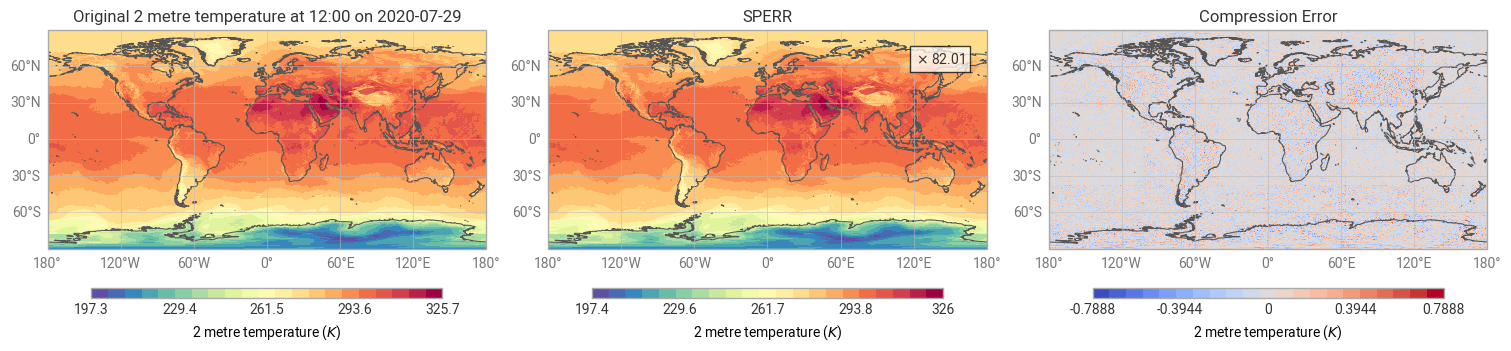

[pyodide]: Memory usage has grown to 1004.0MiB (from 464.4MiB) for this notebook
[pyodide]: Loaded 2 new dynamic libraries (230 total for this notebook)


In [15]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    figsize=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="SPERR", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()